In [2]:
import numpy as np
from data.wm_task import TaskConfig, SternbergWM

cfg = TaskConfig()
task = SternbergWM(cfg)
batch = task.sample_batch(seed=42)
X, Y, meta = batch["X"], batch["Y"], batch["meta"]

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (32, 344, 8)
Y shape: (32, 344, 2)


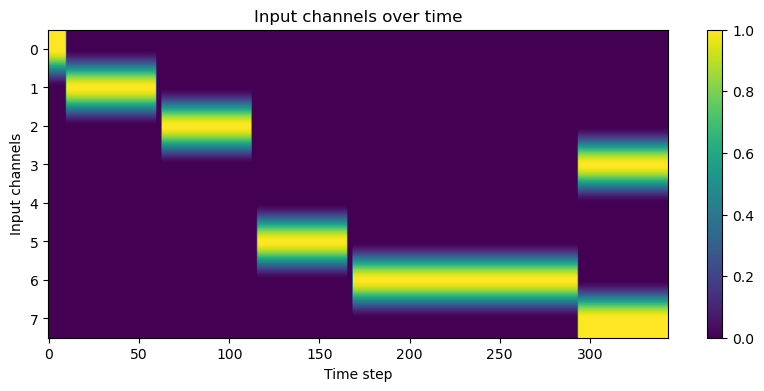

In [3]:
import matplotlib.pyplot as plt

trial = 0
plt.figure(figsize=(10, 4))
plt.imshow(X[trial].T, aspect='auto', cmap='viridis')
plt.title("Input channels over time")
plt.xlabel("Time step")
plt.ylabel("Input channels")
plt.colorbar()
plt.show()


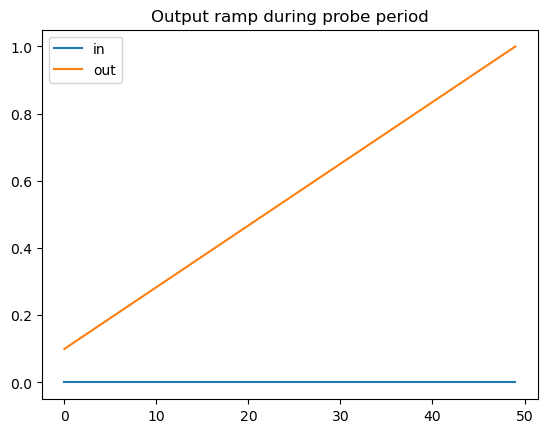

In [4]:
T_probe = cfg.T_probe
Y_probe = Y[0, -T_probe:, :]   # 取出 probe 段输出

plt.plot(Y_probe[:, 0], label="in")
plt.plot(Y_probe[:, 1], label="out")
plt.legend()
plt.title("Output ramp during probe period")
plt.show()


In [1]:
import numpy as np
from data.wm_task import TaskConfig, SternbergWM
from models.rnn_core import RNNConfig, SimpleRNNNumPy, ridge_fit_readout


# 1) 取一批任务数据
cfg = TaskConfig(n_identities=6, max_load=3, batch_size=128, T_probe=30)
task = SternbergWM(cfg)
train_batch = task.sample_batch(seed=1)
Xtr, Ytr = train_batch["X"], train_batch["Y"]

# 2) 初始化小RNN并前向，取隐藏态
rcfg = RNNConfig(input_dim=cfg.n_inputs(), hidden_dim=64, output_dim=2)
rnn = SimpleRNNNumPy(rcfg)
Yhat, H = rnn.forward(Xtr)

# 3) 仅用 probe 窗口做读出拟合（岭回归）
T = cfg.trial_length()
probe = slice(T - cfg.T_probe, T)
Hp = H[:, probe, :].reshape(-1, rcfg.hidden_dim)  # [B*Tprobe, H]
Yp = Ytr[:, probe, :].reshape(-1, 2)              # [B*Tprobe, 2]
Wout = ridge_fit_readout(Hp, Yp, alpha=1e-2)
rnn.set_readout(Wout)

# 4) 在新批次上评估
test_batch = task.sample_batch(seed=2)
Xte, Yte = test_batch["X"], test_batch["Y"]
Ypred, _ = rnn.forward(Xte)
y_pred = Ypred[:, probe, :].mean(axis=1).argmax(axis=1)
y_true = Yte[:,  probe, :].mean(axis=1).argmax(axis=1)
acc = (y_pred == y_true).mean()
print("probe mean-DV acc:", acc)


probe mean-DV acc: 0.5234375


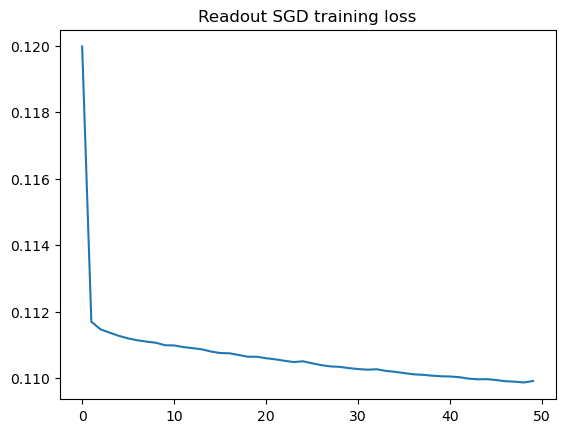

probe mean-DV acc: 0.4921875


In [1]:
from data.wm_task import TaskConfig, SternbergWM
from models.rnn_core import RNNConfig, SimpleRNNNumPy, train_readout_sgd
import numpy as np
import matplotlib.pyplot as plt

# 任务 & 数据
cfg = TaskConfig(n_identities=6, max_load=3, batch_size=512, T_probe=30)
task = SternbergWM(cfg)
train_batch = task.sample_batch(seed=11)
test_batch  = task.sample_batch(seed=12)
Xtr, Ytr = train_batch["X"], train_batch["Y"]
Xte, Yte = test_batch["X"],  test_batch["Y"]

# 小RNN（仍然是随机动力学，只有读出训练）
rcfg = RNNConfig(input_dim=cfg.n_inputs(), hidden_dim=128, output_dim=2,
                 nonlinearity="relu", weight_scale=0.2)
rnn = SimpleRNNNumPy(rcfg)

# 取 probe 段特征与目标
T = cfg.trial_length()
s = slice(T - cfg.T_probe, T)
_, Htr = rnn.forward(Xtr)
Hp = Htr[:, s, :].reshape(-1, rcfg.hidden_dim)  # [B*Tprobe, H]
Yp = Ytr[:, s, :].reshape(-1, 2)                # [B*Tprobe, 2]

# ★ 迭代式训练（有 epochs 和 loss）
W, b, losses = train_readout_sgd(Hp, Yp, epochs=50, lr=5e-2, batch_size=1024)
rnn.set_readout(W, b)

plt.plot(losses); plt.title("Readout SGD training loss"); plt.show()

# 评估（同样用 probe 段的均值 DV）
Yhat, _ = rnn.forward(Xte)
y_pred = Yhat[:, s, :].mean(axis=1).argmax(axis=1)
y_true = Yte[:, s, :].mean(axis=1).argmax(axis=1)
acc = (y_pred == y_true).mean()
print("probe mean-DV acc:", acc)


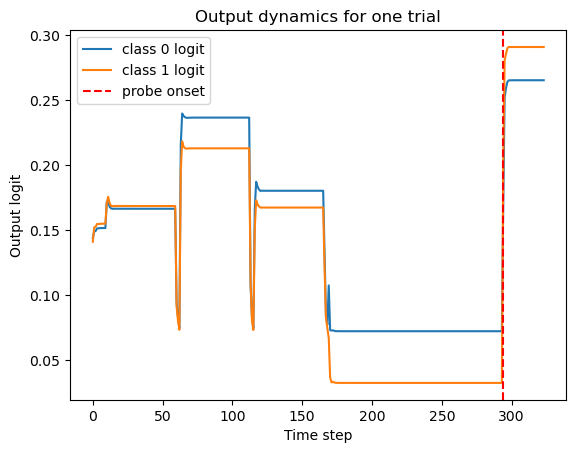

In [2]:
import matplotlib.pyplot as plt

# 选择一个 trial
trial_idx = 0
y_out = Yhat[trial_idx]  # [time, 2]

plt.plot(y_out[:, 0], label='class 0 logit')
plt.plot(y_out[:, 1], label='class 1 logit')
plt.axvline(T - cfg.T_probe, color='red', linestyle='--', label='probe onset')
plt.xlabel("Time step")
plt.ylabel("Output logit")
plt.legend()
plt.title("Output dynamics for one trial")
plt.show()
